# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/helnagar123/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:
!pip -q install datasets duckdb pyarrow matplotlib seaborn

In [8]:
from datasets import load_dataset
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [9]:
# Load datasets from Hugging Face (Arrow format)

content = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    split="train"
)

performance = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train"
)

# Connect DuckDB
con = duckdb.connect()

# Register Arrow tables (no huge Pandas conversion)
con.register("dim_content", content.data.table)
con.register("daily_perf", performance.data.table)

print("Tables loaded successfully!")

print(con.sql("SELECT COUNT(*) FROM dim_content").df())

print(con.sql("SELECT COUNT(*) FROM daily_perf").df())

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

Tables loaded successfully!
   count_star()
0        519606


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   count_star()
0      78835655


In [10]:
con.sql("""
CREATE OR REPLACE VIEW refresh_features AS

SELECT
    p.report_date,

    c.client_hash_id,
    c.content_hash_id,

    c.content_created_date,
    c.content_updated_date,
    c.last_optimized_date,

    c.search_volume,
    c.backlinks,
    c.word_count,
    c.char_count,

    p.gsc_impressions,
    p.gsc_clicks,
    p.gsc_avg_position,

    CASE
        WHEN p.gsc_impressions > 0
        THEN (100.0 * p.gsc_clicks / p.gsc_impressions)
        ELSE NULL
    END AS ctr,

    DATE_DIFF('day', p.report_date, c.content_updated_date) AS content_age_days

FROM daily_perf p

JOIN dim_content c
USING(content_hash_id)

WHERE
    p.gsc_data_available = TRUE
    AND c.is_published = TRUE
    AND c.is_deleted = FALSE
""")

## 1. Distributions

### Distribution overview

Before defining any baseline rule, I inspected the distributions of the main signals used in my Refresh / Content Opportunity lane.

The objective is to identify skewed variables, heavy tails, and unusual values before validating any rule..

In [11]:
summary = con.sql("""

SELECT

COUNT(*) AS rows,

AVG(content_age_days) AS avg_age,

AVG(gsc_impressions) AS avg_impressions,

AVG(gsc_clicks) AS avg_clicks,

AVG(ctr) AS avg_ctr,

AVG(gsc_avg_position) AS avg_position

FROM refresh_features

""").df()

display(summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,avg_age,avg_impressions,avg_clicks,avg_ctr,avg_position
0,28779788,93.201022,61.127921,0.209878,0.356913,17.584052


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

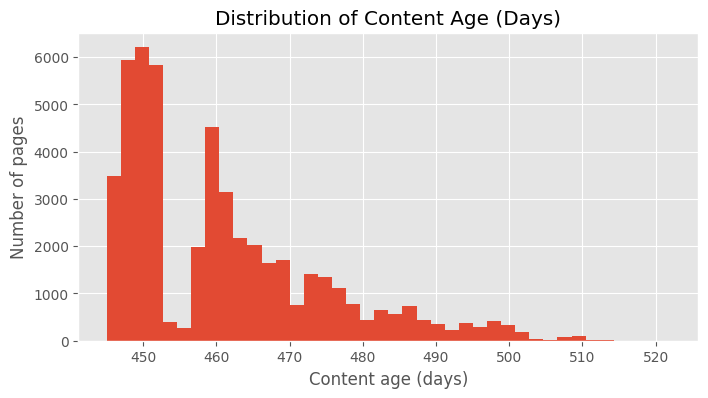

In [16]:
age = con.sql("""

SELECT
content_age_days

FROM refresh_features

WHERE content_age_days IS NOT NULL

LIMIT 50000

""").df()

plt.figure(figsize=(8,4))
plt.hist(age["content_age_days"], bins=40)

plt.title("Distribution of Content Age (Days)")
plt.xlabel("Content age (days)")
plt.ylabel("Number of pages")

plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

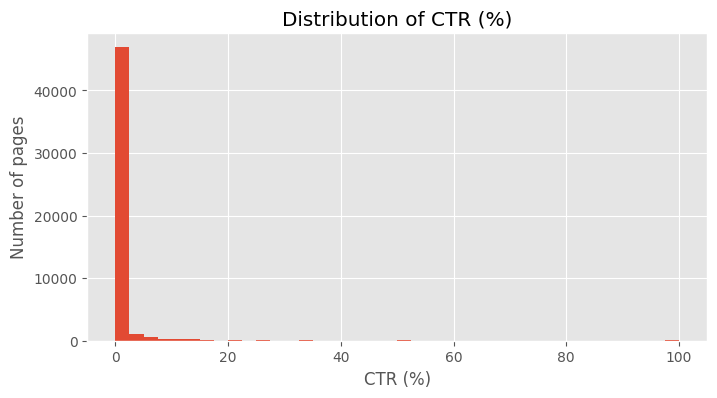

In [17]:
ctr = con.sql("""
SELECT ctr
FROM refresh_features
WHERE ctr IS NOT NULL
LIMIT 50000
""").df()

plt.figure(figsize=(8,4))
plt.hist(ctr["ctr"], bins=40)

plt.title("Distribution of CTR (%)")
plt.xlabel("CTR (%)")
plt.ylabel("Number of pages")

plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

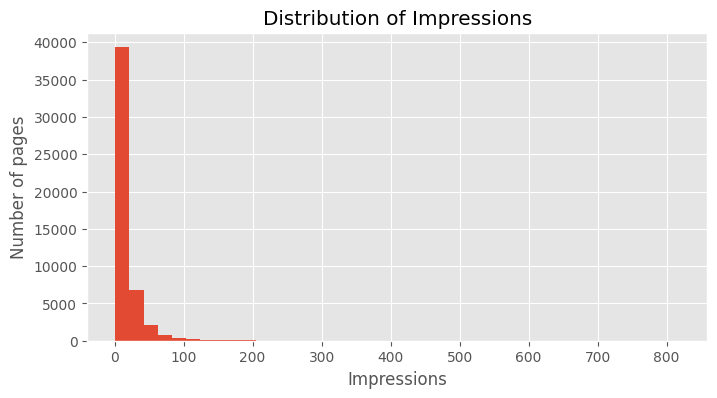

In [18]:
imp = con.sql("""
SELECT gsc_impressions
FROM refresh_features
WHERE gsc_impressions IS NOT NULL
LIMIT 50000
""").df()

plt.figure(figsize=(8,4))
plt.hist(imp["gsc_impressions"], bins=40)

plt.title("Distribution of Impressions")
plt.xlabel("Impressions")
plt.ylabel("Number of pages")

plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

### Signal #1 – Content Age (Staleness)

Hypothesis: Older content is more likely to need refreshing than recently updated content.

Method: Group pages into age buckets and compare their average CTR, impressions, and page count.

In [20]:
age_test = con.sql("""
SELECT
CASE
    WHEN content_age_days < 180 THEN '<180 days'
    WHEN content_age_days < 365 THEN '180-365'
    ELSE '365+'
END AS age_bucket,

COUNT(*) AS n,

AVG(gsc_impressions) AS avg_impressions,

AVG(gsc_clicks) AS avg_clicks,

AVG(ctr) AS avg_ctr

FROM refresh_features

GROUP BY age_bucket

ORDER BY age_bucket
""").df()

display(age_test)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_bucket,n,avg_impressions,avg_clicks,avg_ctr
0,180-365,5069307,54.613878,0.222029,0.372298
1,365+,812638,37.758970,0.209478,0.550006
2,<180 days,22897843,63.399410,0.207203,0.346653


### Verdict: MIXED
Content age alone does not clearly identify refresh opportunities.
Older pages have slightly lower impressions, but they do not consistently show lower CTR or clicks.
This suggests that staleness should be combined with additional signals rather than used alone.

### Signal #2 – CTR

Hypothesis: Pages with low CTR despite receiving impressions are stronger candidates for optimization.

In [21]:
ctr_test = con.sql("""
SELECT

CASE
    WHEN ctr < 0.5 THEN '<0.5%'
    WHEN ctr < 1 THEN '0.5-1%'
    WHEN ctr < 2 THEN '1-2%'
    ELSE '2%+'
END AS ctr_bucket,

COUNT(*) AS n,

AVG(gsc_impressions) AS avg_impressions,

AVG(gsc_clicks) AS avg_clicks,

AVG(gsc_avg_position) AS avg_position

FROM refresh_features

WHERE ctr IS NOT NULL

GROUP BY ctr_bucket

ORDER BY
CASE
    WHEN ctr_bucket='<0.5%' THEN 1
    WHEN ctr_bucket='0.5-1%' THEN 2
    WHEN ctr_bucket='1-2%' THEN 3
    ELSE 4
END
""").df()

display(ctr_test)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,ctr_bucket,n,avg_impressions,avg_clicks,avg_position
0,<0.5%,26356825,51.993210,0.045216,18.419703
1,0.5-1%,709584,315.482394,2.225252,7.669439
2,1-2%,722422,164.138213,2.234864,7.952332
3,2%+,990957,46.858106,1.670096,9.478889


### Verdict: CONFIRMED

Low CTR is associated with weaker organic performance.

Pages in the lowest CTR bucket have the worst average search position and receive almost no clicks.

CTR is therefore a useful signal for identifying optimization opportunities, especially when combined with impressions and search position.

### Signal #3 – Search Volume

Hypothesis: Pages targeting higher-volume keywords represent larger optimization opportunities.

In [22]:
volume_test = con.sql("""
SELECT

CASE
    WHEN search_volume < 100 THEN '<100'
    WHEN search_volume < 1000 THEN '100-1K'
    WHEN search_volume < 10000 THEN '1K-10K'
    ELSE '10K+'
END AS volume_bucket,

COUNT(*) AS n,

AVG(gsc_impressions) AS avg_impressions,

AVG(gsc_clicks) AS avg_clicks,

AVG(ctr) AS avg_ctr

FROM refresh_features

WHERE search_volume IS NOT NULL

GROUP BY volume_bucket

ORDER BY
CASE
    WHEN volume_bucket='<100' THEN 1
    WHEN volume_bucket='100-1K' THEN 2
    WHEN volume_bucket='1K-10K' THEN 3
    ELSE 4
END
""").df()

display(volume_test)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,volume_bucket,n,avg_impressions,avg_clicks,avg_ctr
0,<100,24379676,62.277271,0.218895,0.348166
1,100-1K,2720667,67.675924,0.193788,0.229152
2,1K-10K,615492,55.317557,0.125675,0.172118
3,10K+,64733,47.106731,0.041339,0.196141


### Verdict: MIXED

Search volume alone does not reliably identify the best refresh opportunities.

Higher-volume keywords do not consistently generate higher CTR or more clicks in this dataset.

Search volume should be combined with additional signals such as impressions, ranking position, and CTR before prioritizing content updates.

## Flag-linked Test – Staleness

FlyRank uses freshness (staleness) as one of the signals behind refresh-related flags.

To validate this assumption, I grouped content by age and compared search performance metrics across the buckets.

In [23]:
display(age_test)

,age_bucket,n,avg_impressions,avg_clicks,avg_ctr
0,180-365,5069307,54.613878,0.222029,0.372298
1,365+,812638,37.758970,0.209478,0.550006
2,<180 days,22897843,63.399410,0.207203,0.346653


### Verdict: MIXED

The data does not show a strong negative relationship between content age and organic performance.

Older pages have lower average impressions, but CTR remains comparable or even slightly higher than younger pages.

This indicates that freshness alone should not trigger a refresh recommendation. It should be combined with other quality and performance signals.

## 4. What this means in practice

### Practical takeaway

The signal audit shows that no single metric is sufficient for prioritizing refresh opportunities.

CTR is the strongest standalone signal, while content age and search volume become more useful when combined with additional performance metrics.

The baseline rule should therefore rely on multiple signals rather than a single threshold.

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.